In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

print("Path to dataset files:", path)

c:\Users\koncs\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 54.4M/54.4M [00:03<00:00, 15.8MB/s]

Extracting files...


Path to dataset files: C:\Users\koncs\.cache\kagglehub\datasets\abhi8923shriv\sentiment-analysis-dataset\versions\9


In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os
import re

In [ ]:
import nltk
from nltk import corpus, RegexpTokenizer, PorterStemmer
from nltk.corpus import stopwords
# nltk.download('stopwords')

In [13]:
train_data = pd.read_csv(
    os.path.join(path, 'train.csv'),
    encoding='latin-1'
)

train_data.head(10)

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral,night,70-100,Antigua and Barbuda,97929,440.0,223
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,fun,positive,morning,0-20,Argentina,45195774,2736690.0,17
7,50e14c0bb8,Soooo high,Soooo high,neutral,noon,21-30,Armenia,2963243,28470.0,104
8,e050245fbd,Both of you,Both of you,neutral,night,31-45,Australia,25499884,7682300.0,3
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive,morning,46-60,Austria,9006398,82400.0,109


In [14]:
len(train_data)

27481

In [21]:
extracted_train_data = train_data[['textID', 'text', 'sentiment']]
extracted_train_data.head(4)

,textID,text,sentiment
0,cb774db0d1,"I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative
2,088c60f138,my boss is bullying me...,negative
3,9642c003ef,what interview! leave me alone,negative


In [ ]:
positive_train_data = extracted_train_data[extracted_train_data['sentiment'] == 'positive']['text'].tolist()
negative_train_data = extracted_train_data[extracted_train_data['sentiment'] == 'negative']['text'].tolist()
num_of_pos_text = len(positive_train_data)
num_of_neg_text = len(negative_train_data)
print(f"Number of positive textes: {num_of_pos_text}")
print(f"Number of negative textes: {num_of_neg_text}")

Number of positive textes: 8582
Number of negative textes: 7781


In [27]:
def preprocess_text(text):
    tokenizer = RegexpTokenizer(r'\w+')
    stop_words = stopwords.words('english')
    porter_stemmer = PorterStemmer()
    tokens = tokenizer.tokenize(text)
    lowercased_tokens = [token.lower() for token in tokens]
    tokens_without_stopword = [word for word in lowercased_tokens if word not in stop_words]
    stemmered_tokens = [porter_stemmer.stem(token) for token in tokens_without_stopword]
    return stemmered_tokens


In [37]:
# Create term frequency table (a table that shows the occurences of each word in the positive and negative texts)
from collections import defaultdict

def calculate_term_frequencies_and_tokens(texts):
    term_frequencies = defaultdict(int)
    token_counter = 0
    for text in texts:
        tokens = preprocess_text(text)

        for token in tokens:
            token_counter += 1
            term_frequencies[token] += 1
    return term_frequencies, token_counter

term_frequencies_positive, number_of_pos_tokens = calculate_term_frequencies_and_tokens(positive_train_data)
card_pos_voc = len(term_frequencies_positive)
term_frequencies_negative, number_of_neg_tokens = calculate_term_frequencies_and_tokens(negative_train_data)
card_neg_voc = len(term_frequencies_negative)

        

In [35]:
def calculate_likelihood(term_frequencies, total_terms):
    likelihood = {}
    vocabulary_size = len(term_frequencies)
    for term, frequency in term_frequencies.items():
        likelihood[term] = (frequency + 1)/(total_terms + vocabulary_size)

    return likelihood

In [ ]:
likelihood_positive_class = calculate_likelihood(term_frequencies_positive, number_of_pos_tokens)
likelihood_negative_class = calculate_likelihood(term_frequencies_negative, number_of_neg_tokens)

In [110]:
import math

num_of_textes = num_of_pos_text + num_of_neg_text
log_prior_positive = math.log(num_of_pos_text/num_of_textes)
log_prior_negative = math.log(num_of_neg_text/num_of_textes)

In [ ]:
log_likelihood_pos = {term: math.log(prob) for term, prob in likelihood_positive_class.items()}
log_likelihood_neg = {term: math.log(prob) for term, prob in likelihood_negative_class.items()}

In [123]:
def get_score_of_text(tokens, log_likelihood_sentiment, card_voc_sentiment, num_of_texts_sentiment):
    score = 0
    for token in tokens:
        if token in log_likelihood_sentiment.keys():
            score += log_likelihood_sentiment[token]
        else:
            score += 1/(card_voc_sentiment+num_of_texts_sentiment)
    return score


def classify_text(text, log_likelihood_pos, log_likelihood_neg, log_prior_positive, log_prior_negative):
    tokens = preprocess_text(text)

    # Calculate the log scores
    log_score_positive = log_prior_positive + get_score_of_text(tokens, log_likelihood_pos, card_pos_voc, num_of_pos_text)
    log_score_negative = log_prior_negative + get_score_of_text(tokens, log_likelihood_neg, card_neg_voc, num_of_neg_text)

    sentiment_scores = {'positive': log_score_positive,
                        'negative': log_score_negative }
    
    predicted_sentiment = max(sentiment_scores, key=sentiment_scores.get)
    return predicted_sentiment, sentiment_scores

In [377]:
texts = ["The sun is shining",
         "The weather is not suitable for hiking today",
         "I am unable to predict future exchange rates",
         "A frog is smaller than an elephant",
         "An elephant is bigger than a frog"]

for text in texts:
    sentiment, scores = classify_text(text, log_likelihood_pos, log_likelihood_neg, log_prior_positive, log_prior_negative)
    print(f"sentiment: {sentiment}, scores: pos={scores['positive']}, neg={scores['negative']}")

sentiment: positive, scores: pos=-16.754428181748207, neg=-17.115874780160436
sentiment: negative, scores: pos=-34.22067817245662, neg=-13.07260710921449
sentiment: positive, scores: pos=-48.42726567422643, neg=-49.270258259635945
sentiment: positive, scores: pos=-11.192443279251485, neg=-20.4888432061011
sentiment: negative, scores: pos=-21.04654478449157, neg=-19.97801758233511


In [373]:
test_data = pd.read_csv(
    os.path.join(path, 'test.csv'),
    encoding='latin-1'
)

# this is needed, because the pandas function reads in more row than data existing in csv
len_data = sum(test_data["sentiment"].value_counts())

extracted_test_data = test_data[['text', 'sentiment']]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def test_model(test_dataset, classifier_func):
    y_true = []
    y_pred = []

    for idx, row in test_dataset.iterrows():
        if idx >= len_data:
            break
        
        if row['sentiment'] == 'neutral':
            continue

        pred_sentiment, _ = classifier_func(row['text'], log_likelihood_pos, log_likelihood_neg, log_prior_positive, log_prior_negative)

        y_true.append(row['sentiment'])
        y_pred.append(pred_sentiment)
    
    print(classification_report(y_true, y_pred, target_names=['negative', 'positive']))
    print(confusion_matrix(y_true, y_pred, labels=['negative', 'positive']))

In [374]:
test_model(extracted_test_data, classify_text)

              precision    recall  f1-score   support

    negative       0.69      0.69      0.69      1001
    positive       0.72      0.73      0.72      1103

    accuracy                           0.71      2104
   macro avg       0.71      0.71      0.71      2104
weighted avg       0.71      0.71      0.71      2104

[[687 314]
 [302 801]]


Learning lexicon with Turney`s algorithm

In [ ]:
path_of_imdb_ds = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

path_of_csv = os.path.join(path_of_imdb_ds, "IMDB Dataset.csv")
df=pd.read_csv(path_of_csv)

In [136]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [142]:
print(df['review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [ ]:
import re
import string

def clean_and_lowercase_text(text):
    text=text.lower()

    text=re.sub(r"<.*?>","",text)

    text=re.sub(r"\d+", "", text)

    return text

In [205]:
reviews=df['review']

In [206]:
reviews = reviews.apply(clean_and_lowercase_text)

In [207]:
print(reviews[0])

one of the other reviewers has mentioned that after watching just  oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows woul

In [228]:
# split the documents into sentences

sentences_of_reviews = []
for i in range(len(reviews)): 
    for sentence in re.split('[.!?]', reviews[i]):
        sentences_of_reviews.append((sentence, i))
# # remove puntuations inside sentences
# for i in range(len(sentences)):
#     sentences[i] = sentences[i].translate(str.maketrans("", "",string.punctuation))


In [229]:
print(len(sentences_of_reviews))

781857


In [230]:
sentences_of_reviews[0]

("one of the other reviewers has mentioned that after watching just  oz episode you'll be hooked",
 0)

In [185]:
# First step - searching pos patterns proposed by turney
# pos tagging
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\koncs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\koncs\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [186]:
text = "NLTK is a powerful library for natural language processing."
words = word_tokenize(text)

pos_tags = pos_tag(words)

In [159]:
print("Original Text:")
print(text)

print("\nPoS Tagging Result:")
for word, pos_tag in pos_tags:
    print(f"{word}: {pos_tag}")
    

Original Text:
NLTK is a powerful library for natural language processing.

PoS Tagging Result:
NLTK: NNP
is: VBZ
a: DT
powerful: JJ
library: NN
for: IN
natural: JJ
language: NN
processing: NN
.: .


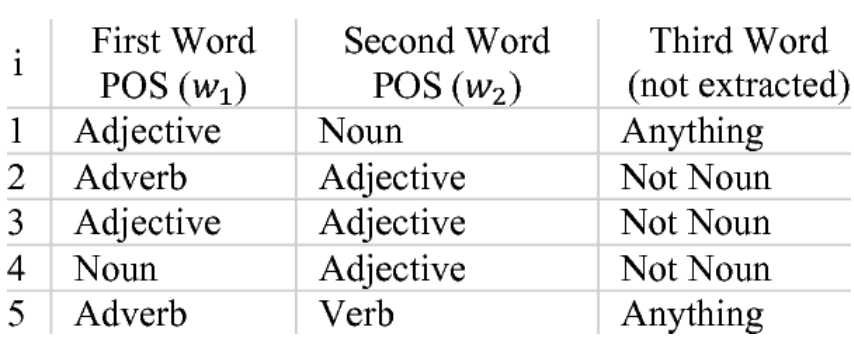

JJ - adjective

NN - Noun, singular or mass

RB - Adverb

VB - Verb

In [265]:
# extract phrases from sentences

allowed_start_tags = ('JJ', 'NN', 'RB')
def retrieve_phrases_from_sentence(sentence):
    phrases_in_sentence = []
    tokens_in_sentence = word_tokenize(sentence)
    pos_tags = pos_tag(tokens_in_sentence)
    
    for i in range(len(pos_tags)-1):
        word, tag = pos_tags[i]
     
        if not tag.startswith(allowed_start_tags):
            continue

        next_word, next_tag = pos_tags[i+1]
        
        next_next_not_noun = False
        if i == len(pos_tags)-2 or not pos_tags[i+2][1].startswith('NN'):
            next_next_not_noun = True

        is_new_phrase = False
        if tag.startswith('JJ'): # 1 or 3 rule
            if next_tag.startswith('NN'):
                is_new_phrase = True                
            elif next_tag.startswith('JJ'):
                if next_next_not_noun:
                    is_new_phrase = True
        elif tag.startswith('RB'): # 2 or 5 rule
            if next_tag.startswith('VB'):
                is_new_phrase = True
            elif next_tag.startswith('JJ'):
                if next_next_not_noun:
                    is_new_phrase = True
        elif tag.startswith('NN'): # 4 rule
            if next_tag.startswith('JJ'):
                if next_next_not_noun:
                    is_new_phrase = True
        if is_new_phrase:
            phrases_in_sentence.append(f"{word} {next_word}")
    
    return phrases_in_sentence



In [266]:
phrases = {}
for sentence, review_idx in sentences_of_reviews:
        phrases_in_sentence = retrieve_phrases_from_sentence(sentence) 
        for phrase in phrases_in_sentence:
            if phrase in phrases:
                phrases[phrase].append(review_idx)
            else:
                phrases[phrase] = [review_idx]

In [268]:
len(phrases)

408814

Semantic orientation of a phrase

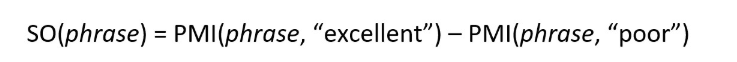

Pointwise Mutual Information

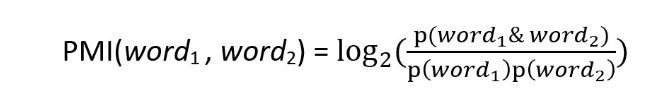


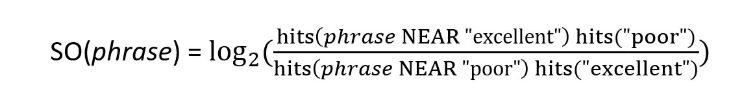

In [241]:
def hits(word, dataset):
    num_of_texts_containing_the_word = 0
    for text in dataset:
        if word in text:
            num_of_texts_containing_the_word += 1
    return num_of_texts_containing_the_word

In [378]:
def hits_near(phrase, word, rev_idxs, reviews):
    pattern = rf"\b({re.escape(word)})\s+(?:\S+\s+){{0,20}}{re.escape(phrase)}\b|\b{re.escape(phrase)}\s+(?:\S+\s+){{0,20}}({re.escape(word)})\b"
    regex = re.compile(pattern, re.IGNORECASE)

    hit_word_phrase = 0
    for rev_idx in rev_idxs:
        hit_word_phrase += len(regex.findall(reviews[rev_idx]))             
    return hit_word_phrase

In [379]:
def calculate_so(phrase, rev_idxs, reviews, total_hit_excellent, total_hit_poor):
    near_excellent = hits_near(phrase, 'excellent', rev_idxs, reviews) 
    near_poor = hits_near(phrase, 'poor', rev_idxs, reviews) 
    
    # if no co-occurrence evidence exists, it's neutral
    if near_excellent == 0 and near_poor == 0:
        return 0

    p_phrase = len(rev_idxs)/len(reviews)

    p_phrase_excellent = (near_excellent + 1)/total_hit_excellent
    p_excellent = total_hit_excellent / len(reviews)

    p_phrase_poor = (near_poor + 1)/total_hit_poor
    p_poor = total_hit_poor / len(reviews)

    pmi_excellent = math.log2(p_phrase_excellent / (p_phrase * p_excellent))
    pmi_poor = math.log2(p_phrase_poor / (p_phrase * p_poor))
    # semantic orientation
    so = pmi_excellent - pmi_poor
    return so
    

In [380]:
hits_of_excellent = hits('excellent', reviews)
hits_of_poor = hits('poor', reviews)

learned_lexicon = {}
for phrase, rev_idxs in phrases.items():
    learned_lexicon[phrase] = calculate_so(phrase, rev_idxs, reviews, hits_of_excellent, hits_of_poor)

In [348]:
# when the window was 20
i = 0
for phrase, so_value in learned_lexicon.items():
    if not so_value == 0:
        print(f"{phrase} = {so_value}")
        i+=1
print(i)

other reviewers = -1.02788542587518
first thing = 0.5570770748459761
other shows = -0.44292292515402365
first episode = 0.14203957556713243
middle class = 1.8790051697333383
only is = 2.3644319969035803
little things = 2.1420395755671326
well done = 1.2940426690121825
serial killer = -1.2502778472116278
never been = 1.8790051697333388
young woman = 0.97211457412482
not be = 0.8201114806797699
more interesting = 1.5570770748459763
little boy = 1.1420395755671324
real life = 2.2940426690121822
instead i = -0.44292292515402387
just ignore = -0.44292292515402387
new york = 0.694580598595911
different characters = 0.5570770748459763
next person = -0.44292292515402343
only thing = 0.29404266901218234
big city = -0.027885425875179504
favorite movie = 1.5570770748459768
never gets = 0.9721145741248198
very few = 1.1420395755671322
only makes = 0.5570770748459766
more fun = 0.97211457412482
white tv = 1.5570770748459761
many movies = 1.1420395755671326
plus points = 0.5570770748459761
then i = 

Extend Model with learned lexicon

In [346]:
def calculate_turney_value(text, learned_lexicon):
    sentences = re.split('[.!?]', clean_and_lowercase_text(text))
    phrases = []
    for sentence in sentences:
        phrases.extend(retrieve_phrases_from_sentence(sentence))
    scores = [learned_lexicon.get(p, 0) for p in phrases]
    return np.mean(scores) if scores else 0.0
        

In [363]:
def classify_text_by_extended_model(text, log_likelihood_pos, log_likelihood_neg, log_prior_positive, log_prior_negative):
    tokens = preprocess_text(text)
    

    # Calculate the log scores
    turney_val = calculate_turney_value(text, learned_lexicon)

    log_score_positive_w_turney = log_prior_positive + get_score_of_text(tokens, log_likelihood_pos, card_pos_voc, num_of_pos_text) + turney_val
    log_score_negative_w_turney = log_prior_negative + get_score_of_text(tokens, log_likelihood_neg, card_neg_voc, num_of_neg_text) - turney_val

    sentiment_scores = {'positive': log_score_positive_w_turney,
                        'negative': log_score_negative_w_turney}
    
    predicted_sentiment = max(sentiment_scores, key=sentiment_scores.get)
    return predicted_sentiment, sentiment_scores

Test results using Naive Bayes

In [372]:
test_model(extracted_test_data, classify_text)

              precision    recall  f1-score   support

    negative       0.69      0.69      0.69      1001
    positive       0.72      0.73      0.72      1103

    accuracy                           0.71      2104
   macro avg       0.71      0.71      0.71      2104
weighted avg       0.71      0.71      0.71      2104

[[687 314]
 [302 801]]






Test results using Naive Bayes + Turney

In [370]:
test_model(extracted_test_data, classify_text_by_extended_model)

              precision    recall  f1-score   support

    negative       0.69      0.67      0.68      1001
    positive       0.71      0.73      0.72      1103

    accuracy                           0.70      2104
   macro avg       0.70      0.70      0.70      2104
weighted avg       0.70      0.70      0.70      2104

[[675 326]
 [301 802]]
